#  **Unstructured Partitioning** 



---

`(1) Env 환경변수`

In [1]:
import os
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

# Poppler와 Tesseract PATH 설정 (hi_res, ocr_only 전략 사용 시 필요)
poppler_path = os.getenv('POPPLER_PATH')
if poppler_path:
    os.environ['PATH'] = poppler_path + os.pathsep + os.environ['PATH']

tessdata_prefix = os.getenv('TESSDATA_PREFIX')
if tessdata_prefix:
    os.environ['TESSDATA_PREFIX'] = tessdata_prefix

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

---

## **파티셔닝(Partitioning) 개념**

- **파티셔닝**은 비정형 문서를 **Title**, **NarrativeText**, **ListItem** 등 구조화된 요소로 분할하는 과정

- 문서의 각 부분을 **의미 있는 단위**로 구분하여 데이터 활용도 향상

- 사용자가 필요한 콘텐츠만 **선택적으로 추출** 가능

---

## **문서별 파티셔닝 전략**

### 1. **PDF/이미지 문서**

`(1) "auto"`

- **auto 전략**은 문서 특성에 따라 최적의 파티셔닝 방법을 자동 선택 (기본 전략)
- 텍스트 추출 가능성에 따라 **fast** 또는 **ocr_only** 전략으로 자동 전환

In [3]:
from unstructured.partition.pdf import partition_pdf

elements = partition_pdf(
    filename="data/transformer.pdf",   
    strategy="auto", 
)

len(elements)

393

In [4]:
def count_elements(elements):
    """문서 구성 요소별 개수 확인"""

    elements_by_type = {}

    for element in elements:
        if "Title" in str(type(element)):
            if "Title" not in elements_by_type:
                elements_by_type["Title"] = []
            elements_by_type["Title"].append(element)

        elif "Table" in str(type(element)):
            if "Table" not in elements_by_type:
                elements_by_type["Table"] = []
            elements_by_type["Table"].append(element)

        elif "Text" in str(type(element)):
            if "Text" not in elements_by_type:
                elements_by_type["Text"] = []
            elements_by_type["Text"].append(element)
        else:
            if "Other" not in elements_by_type:
                elements_by_type["Other"] = []
            elements_by_type["Other"].append(element)

    return elements_by_type


# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Text: 209
Title: 158
Other: 26


In [5]:
# Ohter 타입의 요소 확인
for element in elements_by_type["Other"]:
    print(type(element))

<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class

### **[실습]**

- 종류별로 1개씩 요소를 선택하여 내용과 구조를 분석합니다. 

In [6]:
# Text 타입의 요소 확인
text_el = elements_by_type["Text"][10]

# 요소의 타입 확인
print(f"타입: {type(text_el)}")

# 요소의 텍스트 내용 확인
print(f"\n텍스트 내용:\n{text_el.text}")

# 요소의 메타데이터 확인
print(f"\n메타데이터:")
print(f"  - category: {text_el.category}")
print(f"  - page_number: {text_el.metadata.page_number if hasattr(text_el.metadata, 'page_number') else 'N/A'}")

# 요소를 딕셔너리로 변환하여 전체 구조 확인
print(f"\n전체 구조:")
pprint(text_el.to_dict())

타입: <class 'unstructured.documents.elements.NarrativeText'>

텍스트 내용:
Attention mechanisms have become an integral part of compelling sequence modeling and transduc- tion models in various tasks, allowing modeling of dependencies without regard to their distance in the input or output sequences [2, 19]. In all but a few cases [27], however, such attention mechanisms are used in conjunction with a recurrent network.

메타데이터:
  - category: NarrativeText
  - page_number: 2

전체 구조:
{'element_id': '2ee6dfdc285ed5dae453230809795c6d',
 'metadata': {'coordinates': {'layout_height': 792.0,
                              'layout_width': 612.0,
                              'points': ((107.641, 251.61232159999997),
                                         (107.641, 294.30192159999996),
                                         (505.6553182847998,
                                          294.30192159999996),
                                         (505.6553182847998,
                                

In [7]:
# Title 타입의 요소 확인
title_el = elements_by_type["Title"][10]

# 요소의 타입 확인
print(f"타입: {type(title_el)}")

# 요소의 텍스트 내용 확인
print(f"\n텍스트 내용:\n{title_el.text}")

# 요소의 메타데이터 확인
print(f"\n메타데이터:")
print(f"  - category: {title_el.category}")
print(f"  - page_number: {title_el.metadata.page_number if hasattr(title_el.metadata, 'page_number') else 'N/A'}")

# 요소를 딕셔너리로 변환하여 전체 구조 확인
print(f"\n전체 구조:")
pprint(title_el.to_dict())

타입: <class 'unstructured.documents.elements.Title'>

텍스트 내용:
Abstract

메타데이터:
  - category: Title
  - page_number: 1

전체 구조:
{'element_id': '7a174289db2af5f195316ab12e54a0f3',
 'metadata': {'coordinates': {'layout_height': 792.0,
                              'layout_width': 612.0,
                              'points': ((283.7579999999999, 385.3244368),
                                         (283.7579999999999, 397.2796368),
                                         (328.2432991999999, 397.2796368),
                                         (328.2432991999999, 385.3244368)),
                              'system': 'PixelSpace'},
              'file_directory': 'data',
              'filename': 'transformer.pdf',
              'filetype': 'application/pdf',
              'languages': ['eng'],
              'last_modified': '2025-11-08T21:29:56',
              'page_number': 1},
 'text': 'Abstract',
 'type': 'Title'}


In [8]:
# Other 타입의 요소 확인
other_el = elements_by_type["Other"][0]

# 요소의 타입 확인
print(f"타입: {type(other_el)}")

# 요소의 텍스트 내용 확인 (있는 경우)
if hasattr(other_el, 'text'):
    print(f"\n텍스트 내용:\n{other_el.text}")
else:
    print("\n텍스트 내용: 없음")

# 요소의 메타데이터 확인
print(f"\n메타데이터:")
print(f"  - category: {other_el.category}")
if hasattr(other_el.metadata, 'page_number'):
    print(f"  - page_number: {other_el.metadata.page_number}")

# 요소를 딕셔너리로 변환하여 전체 구조 확인
print(f"\n전체 구조:")
pprint(other_el.to_dict())

타입: <class 'unstructured.documents.elements.Footer'>

텍스트 내용:
31st Conference on Neural Information Processing Systems (NIPS 2017), Long Beach, CA, USA.

메타데이터:
  - category: Footer
  - page_number: 1

전체 구조:
{'element_id': 'c90f5f09633ba98a7afa9851d0e64c69',
 'metadata': {'coordinates': {'layout_height': 792.0,
                              'layout_width': 612.0,
                              'points': ((108.00000000000001, 732.8473424),
                                         (108.00000000000001, 741.8137424),
                                         (460.13742720000016, 741.8137424),
                                         (460.13742720000016, 732.8473424)),
                              'system': 'PixelSpace'},
              'file_directory': 'data',
              'filename': 'transformer.pdf',
              'filetype': 'application/pdf',
              'languages': ['eng'],
              'last_modified': '2025-11-08T21:29:56',
              'page_number': 1},
 'text': '31st Confe

`(2) "fast" `

- **PDF 텍스트 추출**을 위해 pdfminer 라이브러리를 사용
- 텍스트 추출이 가능한 문서에서 **최고 속도**의 처리를 보장

In [9]:
from unstructured.partition.pdf import partition_pdf

fast_elements = partition_pdf(
    filename="data/transformer.pdf",  # PDF 파일 경로 지정
    strategy="fast",                  # 파티셔닝 전략 설정 
    include_page_breaks=True          # 페이지 구분자(PageBreak 요소)를 포함
)

# 문서 구성 요소 개수 확인
len(fast_elements)

408

In [10]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(fast_elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Text: 209
Title: 158
Other: 41


In [11]:
# Ohter 타입의 요소 확인
for element in elements_by_type["Other"]:
    print(type(element))

<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.Footer'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements

In [12]:
# page break 포함해서 일부만 확인
for element in fast_elements[:25]:
    if element.category == "PageBreak":
        print("-- Page Break --")
        print(element.text)
        
    else:
        print(element.text)

3 2 0 2
g u A 2
] L C . s c [
7 v 2 6 7 3 0 . 6 0 7 1 : v i X r a
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.
Attention Is All You Need
Ashish Vaswani∗ Google Brain avaswani@google.com
Noam Shazeer∗ Google Brain noam@google.com
Niki Parmar∗ Google Research nikip@google.com
Jakob Uszkoreit∗ Google Research usz@google.com
Llion Jones∗ Google Research llion@google.com
Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu
Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com
Illia Polosukhin∗ ‡ illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mec

### **[실습]**

- Footer를 제외한 나머지 요소는 원래 순서를 유지한 채로 재구조화합니다. (Footer 요소만 제거) 

In [13]:
# Footer를 제외한 나머지 요소는 원래 순서를 유지한 채로 재구조화
# Footer 요소만 제거

cleaned_elements = []

for element in fast_elements:
    # Footer 요소가 아닌 경우만 추가
    if element.category != "Footer":
        cleaned_elements.append(element)

print(f"원본 요소 개수: {len(fast_elements)}")
print(f"정리된 요소 개수: {len(cleaned_elements)}")
print(f"제거된 Footer 개수: {len(fast_elements) - len(cleaned_elements)}")

원본 요소 개수: 408
정리된 요소 개수: 393
제거된 Footer 개수: 15


In [14]:
# 문서 요소를 출력 
for element in cleaned_elements[:30]:
    print(element.text)

3 2 0 2
g u A 2
] L C . s c [
7 v 2 6 7 3 0 . 6 0 7 1 : v i X r a
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.
Attention Is All You Need
Ashish Vaswani∗ Google Brain avaswani@google.com
Noam Shazeer∗ Google Brain noam@google.com
Niki Parmar∗ Google Research nikip@google.com
Jakob Uszkoreit∗ Google Research usz@google.com
Llion Jones∗ Google Research llion@google.com
Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu
Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com
Illia Polosukhin∗ ‡ illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mec

`(3) "hi_res" `

- **문서 레이아웃 분석**을 위해 객체 탐지 모델을 활용
- 높은 정밀도가 필요한 문서 요소 **분류 작업**에 적합
- 레이아웃 기반으로 **문서 구조 정보**를 상세하게 추출할 수 있음 

In [15]:
from unstructured.partition.pdf import partition_pdf

# PDF 문서를 고해상도 전략으로 파티셔닝하고 이미지/테이블을 추출
hi_res_elements = partition_pdf(
    # 기본 설정
    filename="data/transformer.pdf",    # 처리할 PDF 파일의 경로
    strategy="hi_res",                  # 고해상도 파티셔닝 전략 사용
    hi_res_model_name="yolox",  # 객체탐지 모델 지정 
    
    # 구조 분석 설정
    infer_table_structure=True,         # 표 구조를 자동으로 추론하여 HTML 형식으로 변환
    languages=["eng", "kor"],           # 영어와 한국어 문서 처리 지원
    
    # 이미지 추출 설정
    extract_images_in_pdf=True,         # PDF 내 이미지 추출 활성화
    extract_image_block_types=[         # 추출할 요소 유형 지정
        "Image",                        # 일반 이미지
        "Table"                         # 표 이미지
    ],
    extract_image_block_output_dir="output_images"  # 추출된 이미지 저장 경로
)

# 문서 구성 요소 개수 확인
len(hi_res_elements)

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


220

In [16]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(hi_res_elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Text: 118
Other: 71
Title: 27
Table: 4


In [17]:
# 테이블 요소 확인
table_elements = elements_by_type["Table"]
table_elements[0]

In [18]:
# 테이블 요소의 속성 확인
table_elements[0].to_dict()

{'type': 'Table',
 'element_id': '6f5f77d6495bac8a58d400cf653acdc6',
 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)',
 'metadata': {'detection_class_prob': 0.928255021572113,
  'coordinates': {'points': ((np.float64(320.3291931152344),
     np.float64(312.45477294921875)),
    (np.float64(320.3291931152344), np.float64(519.1640014648438)),
    (np.float64(1363.98291015625), np.float64(519.1640014648438)),
    (np.float64(1363.98291015625), np.float64(312.45477294921875))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2025-11-08T21:29:56',
  'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td><td>O(n? - d

In [19]:
# 테이블 요소의 HTML 텍스트 확인
table_elements[0].metadata.text_as_html

'<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td><td>O(n? - d)</td><td>0200)</td><td>0200)</td></tr><tr><td>Recurrent</td><td>O(n - d?)</td><td>O(n)</td><td>O(n)</td></tr><tr><td>Convolutional</td><td>O(k-n-d?)</td><td>02010)</td><td>O(logx(n))</td></tr><tr><td>Self-Attention (restricted)</td><td>O(r-n-d)</td><td>020)</td><td>O(n/r)</td></tr></tbody></table>'

In [20]:
# 판다스 데이터프레임으로 변환
df = pd.read_html(table_elements[0].metadata.text_as_html)[0]
df

,Layer Type,Complexity per Layer,Sequential Operations,Maximum Path Length
0,Self-Attention,O(n? - d),0200),0200)
1,Recurrent,O(n - d?),O(n),O(n)
2,Convolutional,O(k-n-d?),02010),O(logx(n))
3,Self-Attention (restricted),O(r-n-d),020),O(n/r)


In [21]:
# 마크다운 형식으로 변환
print(df.to_markdown())

|    | Layer Type                  | Complexity per Layer   | Sequential Operations   | Maximum Path Length   |
|---:|:----------------------------|:-----------------------|:------------------------|:----------------------|
|  0 | Self-Attention              | O(n? - d)              | 0200)                   | 0200)                 |
|  1 | Recurrent                   | O(n - d?)              | O(n)                    | O(n)                  |
|  2 | Convolutional               | O(k-n-d?)              | 02010)                  | O(logx(n))            |
|  3 | Self-Attention (restricted) | O(r-n-d)               | 020)                    | O(n/r)                |


### **[실습]**

- 두 번째 테이블 요소를 마크다운과 데이터프레임 형식으로 변환합니다. 
- 변환된 데이터를 LLM에 전달하여 내용을 요약하고, 그 결과를 비교합니다. 

In [22]:
# 두 번째 테이블 요소 확인
table_elements[1].to_dict()

{'type': 'Table',
 'element_id': '7dce43ff5681af530b1d93a5bafa0262',
 'text': 'Model BLEU EN-DE EN-FR Training Cost (FLOPs) EN-DE EN-FR ByteNet [18] 23.75 Deep-Att + PosUnk [39] 39.2 1.0 · 1020 GNMT + RL [38] 24.6 39.92 2.3 · 1019 1.4 · 1020 ConvS2S [9] 25.16 40.46 9.6 · 1018 1.5 · 1020 MoE [32] 26.03 40.56 2.0 · 1019 1.2 · 1020 Deep-Att + PosUnk Ensemble [39] 40.4 8.0 · 1020 GNMT + RL Ensemble [38] 26.30 41.16 1.8 · 1020 1.1 · 1021 ConvS2S Ensemble [9] 26.36 41.29 7.7 · 1019 1.2 · 1021 Transformer (base model) 27.3 38.1 3.3 · 1018 Transformer (big) 28.4 41.8 2.3 · 1019',
 'metadata': {'detection_class_prob': 0.9288275837898254,
  'coordinates': {'points': ((np.float64(362.89111328125),
     np.float64(266.6315002441406)),
    (np.float64(362.89111328125), np.float64(676.1827392578125)),
    (np.float64(1332.961669921875), np.float64(676.1827392578125)),
    (np.float64(1332.961669921875), np.float64(266.6315002441406))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_h

In [23]:
# 두 번째 테이블 요소를 데이터프레임으로 변환
df2 = pd.read_html(table_elements[1].metadata.text_as_html)[0]
print(f"데이터프레임 크기: {df2.shape[0]} rows × {df2.shape[1]} columns")
print("\n데이터프레임:")
df2

데이터프레임 크기: 10 rows × 5 columns

데이터프레임:


,Model,EN-DE,BLEU EN-FR,Training EN-DE,Cost (FLOPs) EN-FR
0,ByteNet [18] 23.75,ByteNet [18] 23.75,ByteNet [18] 23.75,ByteNet [18] 23.75,ByteNet [18] 23.75
1,Deep-Att + PosUnk,NaN,39.2,NaN,1.0 - 107°
2,GNMT + RL 8],24.6,39.92,2.3-10!9,1.4. 1070
3,ConvS28S [이,25.16,40.46,9.6-10'%,1.5-1070
4,MoE,26.03,40.56,2.0-10'9,1.2. 107°
5,Deep-Att + PosUnk Ensemble,NaN,40.4,NaN,8.0 - 107°
6,GNMT + RL Ensemble (33,26.30,41.16,1.8-1079,1.1- 1074
7,ConvS2S Ensemble [의,26.36,41.29,7.7-10'9,1.2.10?!
8,Transformer (base model),27.3,38.1,3.3 -,1018
9,Transformer (big),28.4,41.8,2.3.,1019


In [24]:
# 마크다운 형식으로 변환
markdown_table = df2.to_markdown(index=False)
print("마크다운 형식:")
print(markdown_table)

마크다운 형식:
| Model                      | EN-DE              | BLEU EN-FR         | Training EN-DE     | Cost (FLOPs) EN-FR   |
|:---------------------------|:-------------------|:-------------------|:-------------------|:---------------------|
| ByteNet [18] 23.75         | ByteNet [18] 23.75 | ByteNet [18] 23.75 | ByteNet [18] 23.75 | ByteNet [18] 23.75   |
| Deep-Att + PosUnk          | nan                | 39.2               | nan                | 1.0 - 107°           |
| GNMT + RL 8]               | 24.6               | 39.92              | 2.3-10!9           | 1.4. 1070            |
| ConvS28S [이               | 25.16              | 40.46              | 9.6-10'%           | 1.5-1070             |
| MoE                        | 26.03              | 40.56              | 2.0-10'9           | 1.2. 107°            |
| Deep-Att + PosUnk Ensemble | nan                | 40.4               | nan                | 8.0 - 107°           |
| GNMT + RL Ensemble (33     | 26.30              | 41.1

In [25]:
# 세 번째 테이블 요소 확인
print("=== 테이블 3 (Table 3) ===")
print(table_elements[2].to_dict())

=== 테이블 3 (Table 3) ===
{'type': 'Table', 'element_id': '2abed00f4d8b169d438c98b763a1731e', 'text': 'N dmodel dff h dk dv Pdrop ϵls train steps PPL (dev) BLEU params (dev) ×106 base 6 512 2048 8 64 64 0.1 0.1 100K 4.92 25.8 65 1 512 512 5.29 24.9 (A) 4 16 128 32 128 32 5.00 4.91 25.5 25.8 32 16 16 5.01 25.4 (B) 16 32 5.16 5.01 25.1 25.4 58 60 2 6.11 23.7 36 4 5.19 25.3 50 8 4.88 25.5 80 (C) 256 32 32 5.75 24.5 28 1024 128 128 4.66 26.0 168 1024 5.12 25.4 53 4096 4.75 26.2 90 0.0 5.77 24.6 (D) 0.2 0.0 4.95 4.67 25.5 25.3 0.2 5.47 25.7 (E) positional embedding instead of sinusoids 4.92 25.7', 'metadata': {'detection_class_prob': 0.9245283007621765, 'coordinates': {'points': ((np.float64(300.62860107421875), np.float64(356.70068359375)), (np.float64(300.62860107421875), np.float64(1062.924560546875)), (np.float64(1406.045654296875), np.float64(1062.924560546875)), (np.float64(1406.045654296875), np.float64(356.70068359375))), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 

In [27]:
# 세 번째 테이블 요소를 데이터프레임으로 변환
df3 = pd.read_html(table_elements[2].metadata.text_as_html)[0]
print(f"데이터프레임 크기: {df3.shape[0]} rows × {df3.shape[1]} columns")
print("데이터프레임:")
df3

데이터프레임 크기: 20 rows × 13 columns
데이터프레임:


,Unnamed: 0,No,아바,de,Unnamed: 4,Rd,dy,Parop,ets,fame,| deny,dev).,dO
0,base,| 6,512.0,2048,8,64.0,64,0.1,0.1,100K,| 4.92,25.8,65.0
1,(A),NaN,NaN,NaN,1,512.0,512,NaN,NaN,NaN,5.29,24.9,NaN
2,(A),NaN,NaN,NaN,4,128.0,128,NaN,NaN,NaN,5.00,25.5,NaN
3,(A),NaN,NaN,NaN,16,32.0,32,NaN,NaN,NaN,491,25.8,NaN
4,(A),NaN,NaN,NaN,32,16.0,16,NaN,NaN,NaN,5.01,25.4,NaN
5,08),NaN,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN,5.16,25.1,58.0
6,08),NaN,NaN,NaN,NaN,32.0,NaN,NaN,NaN,NaN,5.01,25.4,60.0
7,(C),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.11,23.7,36.0
8,(C),4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.19,25.3,50.0
9,(C),8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.88,25.5,80.0


In [28]:
# 네 번째 테이블 요소 확인
print("=== 테이블 4 (Table 4) ===")
print(table_elements[3].to_dict())

=== 테이블 4 (Table 4) ===
{'type': 'Table', 'element_id': '3545b0e8813c3c4571016088f8a57aeb', 'text': 'Parser Training WSJ 23 F1 Vinyals & Kaiser el al. (2014) [37] WSJ only, discriminative 88.3 Petrov et al. (2006) [29] WSJ only, discriminative 90.4 Zhu et al. (2013) [40] WSJ only, discriminative 90.4 Dyer et al. (2016) [8] WSJ only, discriminative 91.7 Transformer (4 layers) WSJ only, discriminative 91.3 Zhu et al. (2013) [40] semi-supervised 91.3 Huang & Harper (2009) [14] semi-supervised 91.3 McClosky et al. (2006) [26] semi-supervised 92.1 Vinyals & Kaiser el al. (2014) [37] semi-supervised 92.1 Transformer (4 layers) semi-supervised 92.7 Luong et al. (2015) [23] multi-task 93.0 Dyer et al. (2016) [8] generative 93.3', 'metadata': {'detection_class_prob': 0.9149760603904724, 'coordinates': {'points': ((np.float64(391.6229553222656), np.float64(259.5727233886719)), (np.float64(391.6229553222656), np.float64(658.9208374023438)), (np.float64(1303.801025390625), np.float64(658.920837402

In [30]:
# 네 번째 테이블 요소를 데이터프레임으로 변환
df4 = pd.read_html(table_elements[3].metadata.text_as_html)[0]
print(f"데이터프레임 크기: {df4.shape[0]} rows × {df4.shape[1]} columns")
print("데이터프레임:")
df4

데이터프레임 크기: 12 rows × 3 columns
데이터프레임:


,Parser,Training,WSJ 23 F1
0,Vinyals & Kaiser el al. (2014),"WSJ only, discriminative",88.3
1,Petrov et al. (2006),"WSJ only, discriminative",90.4
2,Zhu et al. (2013) [4 이,"WSJ only, discriminative",90.4
3,Dyer et al. (2016),"WSJ only, discriminative",91.7
4,Transformer (4 layers),"WSJ only, discriminative",91.3
5,Zhu et al. (2013) [40],semi-supervised,913.0
6,Huang & Harper (2009),semi-supervised,91.3
7,McClosky et al. (2006),semi-supervised,92.1
8,Vinyals & Kaiser el al. (2014),semi-supervised,92.1
9,Transformer (4 layers),semi-supervised,92.7


In [31]:
# LLM에 각 데이터를 전달하여 내용 요약 (마크다운 형식)
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate

llm = ChatOpenAI(model="gpt-4o-mini")   

# 프롬프트 템플릿 정의
prompt_template = PromptTemplate(
    input_variables=["table"],
    template="Summarize the table:\n\n[Table]\n{table}\n\n[Summary (in 한국어)]\n"
)
# 프롬프트 템플릿 생성
prompt = prompt_template.format(table=df2.to_markdown())

# LLM에 프롬프트 전달하여 요약 생성
summary = llm.invoke(prompt)

# 요약 결과 출력
pprint(summary.content)

('이 표는 여러 모델의 번역 성능과 관련된 메트릭을 비교합니다. 모델은 EN-DE 및 BLEU EN-FR 점수, 학습 과정에서의 파라미터 '
 '수, 그리고 비용(FLOPs)으로 나뉘어 있습니다. 주요 내용을 요약하면 다음과 같습니다:\n'
 '\n'
 '1. **ByteNet**은 모든 메트릭에서 동일한 점수(23.75)를 보이며, 다른 모델과 비교할 때 가장 낮은 성능을 보입니다.\n'
 '2. **GNMT + RL**은 EN-DE에서 24.6, BLEU EN-FR에서 39.92를 기록, 학습 파라미터 수는 '
 '2.3-10^9입니다.\n'
 '3. **ConvS28S**는 EN-DE와 BLEU EN-FR 모두에서 더 높은 성능(25.16 및 40.46)을 보이고, 학습과정에서 '
 "9.6-10'9 개의 파라미터를 사용합니다.\n"
 '4. **MoE** 모델은 EN-DE에서 26.03, BLEU EN-FR에서 40.56으로 더 나은 성능을 기록합니다.\n'
 '5. **Deep-Att + PosUnk Ensemble**과 **GNMT + RL Ensemble**은 각각 40.4와 41.16의 '
 'BLEU 점수를 보이며, 후자는 EN-DE에서 26.30에 해당합니다.\n'
 '6. **Transformer (base model)**은 EN-DE에서 27.3, BLEU EN-FR에서 38.1의 성능을 보이며, '
 '**Transformer (big)**는 EN-DE 28.4 및 BLEU EN-FR 41.8로 가장 높은 성능을 기록합니다.\n'
 '\n'
 '모델의 비용(FLOPs)과 학습 파라미터 수 역시 다양한 수치로 주어져 있습니다, 이들은 모델의 복잡성과 연산량을 드러냅니다.')


In [32]:
# 데이터프레임을 문자열로 변환하여 출력
print(str(df2))

                        Model               EN-DE          BLEU EN-FR  \
0          ByteNet [18] 23.75  ByteNet [18] 23.75  ByteNet [18] 23.75   
1           Deep-Att + PosUnk                 NaN                39.2   
2                GNMT + RL 8]                24.6               39.92   
3                 ConvS28S [이               25.16               40.46   
4                         MoE               26.03               40.56   
5  Deep-Att + PosUnk Ensemble                 NaN                40.4   
6      GNMT + RL Ensemble (33               26.30               41.16   
7         ConvS2S Ensemble [의               26.36               41.29   
8    Transformer (base model)                27.3                38.1   
9           Transformer (big)                28.4                41.8   

       Training EN-DE  Cost (FLOPs) EN-FR  
0  ByteNet [18] 23.75  ByteNet [18] 23.75  
1                 NaN          1.0 - 107°  
2            2.3-10!9           1.4. 1070  
3            9.6-10'

In [33]:
# LLM에 각 데이터를 전달하여 내용 요약 (데이터프레임 형식)
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate

llm = ChatOpenAI(model="gpt-4o-mini")

# 프롬프트 템플릿 정의
prompt_template = PromptTemplate(
    input_variables=["table"],
    template="Summarize the table:\n\n[Table]\n{table}\n\n[Summary (in 한국어)]\n"
)

# 프롬프트 템플릿 생성
prompt = prompt_template.format(table=str(df2))

# LLM에 프롬프트 전달하여 요약 생성
summary = llm.invoke(prompt)

# 요약 결과 출력
pprint(summary.content)

('이 표는 여러 번역 모델의 성능을 비교하고 있습니다. 각각의 모델은 EN-DE와 EN-FR 언어 쌍에 대한 BLEU 점수와 훈련 '
 '비용(플롭수)을 나타내고 있습니다.\n'
 '\n'
 '1. **모델 성능**:\n'
 '   - ByteNet 모델이 EN-DE와 EN-FR 모두에서 동일한 BLEU 점수인 23.75를 기록하였습니다.\n'
 '   - GNMT + RL 모델은 EN-DE에서 24.6점, EN-FR에서는 39.92점을 기록했습니다.\n'
 '   - ConvS2S와 MoE 모델은 EN-DE에서 각각 25.16점과 26.03점을 기록했습니다.\n'
 '   - Transformer 모델(based와 big)에 대한 성능은 각각 27.3점 (base)과 28.4점 (big)입니다.\n'
 '\n'
 '2. **훈련 비용**:\n'
 '   - 훈련 비용은 모델에 따라 다르며, 대부분은 특정 숫자 범위로 나타나 있습니다.\n'
 '   - 예를 들어, MoE 모델은 EN-DE에서 2.0 x 10^9의 훈련 비용을 요구했습니다.\n'
 '\n'
 '결과적으로, 전반적으로 NUM(23.75-28.4) 범위의 BLEU 점수를 가진 모델들이 있으며, 훈련 비용은 모델에 따라 다르지만 '
 '대체로 고성능 모델들이 더 높은 비용을 요구하는 경향을 보입니다.')


`(4) "ocr_only"`

- **Tesseract OCR**을 활용한 텍스트 추출 방식을 채택
- **다중 열 구조**의 복잡한 문서에서 hi_res의 대안으로 사용
- 이미지 기반 문서의 **텍스트 인식**에 특화

In [34]:
from unstructured.partition.pdf import partition_pdf

ocr_elements = partition_pdf(
    filename="data/transformer.pdf",     
    strategy="ocr_only",                 
    languages=["eng", "kor"],            # 문서에 포함된 언어를 지정 (메타데이터에 기록)
    max_partition=1500                   # 최대 텍스트 분할 크기(문자 수) 
)

# 문서 구성 요소 개수 확인
len(ocr_elements)

260

In [35]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(ocr_elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Text: 184
Title: 73
Other: 3


In [36]:
# Ohter 타입의 요소 확인
for element in elements_by_type["Other"]:
    print(type(element))

<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>


### **[실습]**

- 다음 pdf 문서를 hi_res와 ocr_only 전략으로 변환합니다. 
    - data/리비안_KR_with_table.pdf
    
- 테이블 부분을 찾아서 내용과 구조를 확인합니다. 

In [37]:
# 문서(data/리비안_KR_with_table.pdf) 파티셔닝 - OCR 전략
test_ocr_elements = partition_pdf(
    filename="data/리비안_KR_with_table.pdf",
    strategy="ocr_only",
    languages=["eng", "kor"],
    max_partition=1500
)

# 문서 구성 요소 개수 확인
print(f"OCR 전략 요소 개수: {len(test_ocr_elements)}")

# 문서 구성 요소별 개수 확인
test_ocr_elements_by_type = count_elements(test_ocr_elements)

print("\n구성 요소별 개수:")
for key, value in test_ocr_elements_by_type.items():
    print(f"  {key}: {len(value)}")

# Other 타입의 요소 확인
print("\nOther 타입:")
for element in test_ocr_elements_by_type.get("Other", []):
    print(f"  {type(element)}")

Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBB

OCR 전략 요소 개수: 88

구성 요소별 개수:
  Title: 35
  Text: 48
  Other: 5

Other 타입:
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>


In [38]:
# 테이블 위치의 요소 확인 - 텍스트에 "순이익 (백만 USD)" 포함
test_ocr_el = None

for element in test_ocr_elements:
    if "순이익" in element.text or "백만 USD" in element.text:
        test_ocr_el = element
        print(f"찾은 요소:")
        print(f"  - 타입: {type(element)}")
        print(f"  - 텍스트 미리보기: {element.text[:100]}...")
        break

if test_ocr_el:
    # 테이블 요소의 속성 확인
    print("\n요소 전체 구조:")
    pprint(test_ocr_el.to_dict())
else:
    print("'순이익 (백만 USD)'가 포함된 요소를 찾을 수 없습니다.")
    print("첫 10개 요소 텍스트 확인:")
    for i, element in enumerate(test_ocr_elements[:10]):
        print(f"{i}: {element.text[:50]}...")

찾은 요소:
  - 타입: <class 'unstructured.documents.elements.Text'>
  - 텍스트 미리보기: e 순이익 (2023): -54 억 미국 달러...

요소 전체 구조:
{'element_id': 'dcecdf8bd78803a54880980ba26e0076',
 'metadata': {'coordinates': {'layout_height': 2339,
                              'layout_width': 1653,
                              'points': ((np.float64(169.0), np.float64(805.0)),
                                         (np.float64(169.0), np.float64(842.0)),
                                         (np.float64(587.0), np.float64(842.0)),
                                         (np.float64(587.0),
                                          np.float64(805.0))),
                              'system': 'PixelSpace'},
              'file_directory': 'data',
              'filename': '리비안_KR_with_table.pdf',
              'filetype': 'application/pdf',
              'languages': ['kor'],
              'last_modified': '2025-11-08T21:29:56',
              'page_number': 1,
              'parent_id': '826d29252b4ec32617ec

In [39]:
# 문서(data/리비안_KR_with_table.pdf) 파티셔닝 - high_res 전략
test_hi_res_elements = partition_pdf(
    filename="data/리비안_KR_with_table.pdf",
    strategy="hi_res",
    hi_res_model_name="yolox",
    infer_table_structure=True,
    languages=["eng", "kor"],
    extract_images_in_pdf=False
)

# 문서 구성 요소 개수 확인
print(f"Hi-res 전략 요소 개수: {len(test_hi_res_elements)}")

# 문서 구성 요소별 개수 확인
test_hi_res_elements_by_type = count_elements(test_hi_res_elements)

print("\n구성 요소별 개수:")
for key, value in test_hi_res_elements_by_type.items():
    print(f"  {key}: {len(value)}")

# Other 타입의 요소 확인
print("\nOther 타입:")
for element in test_hi_res_elements_by_type.get("Other", []):
    print(f"  {type(element)}")

Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBB

Hi-res 전략 요소 개수: 96

구성 요소별 개수:
  Other: 43
  Text: 41
  Title: 11
  Table: 1

Other 타입:
  <class 'unstructured.documents.elements.Header'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'unstructured.documents.elements.ListItem'>
  <class 'un

In [40]:
# 테이블 위치의 요소 확인
test_hi_res_el = None

# Table 요소가 있는지 확인
if "Table" in test_hi_res_elements_by_type:
    test_hi_res_el = test_hi_res_elements_by_type["Table"][0]
    print(f"테이블 요소 발견:")
    print(f"  - 타입: {type(test_hi_res_el)}")
    print(f"  - 텍스트 길이: {len(test_hi_res_el.text)}")
    
    # 테이블 요소의 속성 확인
    print("\n요소 전체 구조:")
    pprint(test_hi_res_el.to_dict())
else:
    print("Table 요소를 찾을 수 없습니다.")
    print("대신 '순이익'이 포함된 텍스트 요소를 찾습니다.")
    
    for element in test_hi_res_elements:
        if "순이익" in element.text or "백만 USD" in element.text:
            test_hi_res_el = element
            print(f"\n찾은 요소:")
            print(f"  - 타입: {type(element)}")
            print(f"  - 텍스트: {element.text[:200]}...")
            pprint(test_hi_res_el.to_dict())
            break

테이블 요소 발견:
  - 타입: <class 'unstructured.documents.elements.Table'>
  - 텍스트 길이: 91

요소 전체 구조:
{'element_id': '8df6f5346998c684c8a2560208af5afd',
 'metadata': {'coordinates': {'layout_height': 2339,
                              'layout_width': 1653,
                              'points': ((np.float64(113.9568862915039),
                                          np.float64(1791.0799560546875)),
                                         (np.float64(113.9568862915039),
                                          np.float64(2051.089599609375)),
                                         (np.float64(920.7163696289062),
                                          np.float64(2051.089599609375)),
                                         (np.float64(920.7163696289062),
                                          np.float64(1791.0799560546875))),
                              'system': 'PixelSpace'},
              'detection_class_prob': 0.8305203318595886,
              'file_directory': 'data',
       

In [41]:
# 테이블 요소의 HTML 텍스트 확인
test_hi_res_el.metadata.text_as_html

'<table><thead><tr><th>2020</th><th>0</th><th>-1,018</th><th>4,602</th></tr></thead><tbody><tr><td>2021</td><td>55</td><td>-4,688</td><td>22,294</td></tr><tr><td>2022</td><td>1,658</td><td>-6,752</td><td>17,876</td></tr><tr><td>2023</td><td>4,434</td><td>-5,432</td><td>16,778</td></tr></tbody></table>'

In [42]:
# 판다스 데이터프레임으로 변환
df = pd.read_html(test_hi_res_el.metadata.text_as_html)[0]
df

,2020,0,"-1,018","4,602"
0,2021,55,-4688,22294
1,2022,1658,-6752,17876
2,2023,4434,-5432,16778


### 2. **HTML**

- **웹 문서 구조**를 분석하여 HTML 요소를 체계적으로 추출
- **URL 기반**으로 웹 페이지를 직접 처리 가능

`(1) "로컬 파일"`

- **partition_html** 함수는 로컬에 저장된 HTML 파일을 읽어 **문서 요소로 분할**

- `filename` 매개변수를 통해 **로컬 HTML 파일의 경로**를 지정 가능

In [43]:
from unstructured.partition.html import partition_html

# 로컬 파일
elements = partition_html(filename="data/example.html")

# 문서 구성 요소 개수 확인
len(elements)

3

In [44]:
# 문서 구성 요소 확인
for element in elements:
    print(element.to_dict())

{'type': 'Title', 'element_id': 'ded3195e84606230d07e8bbef9b8b7df', 'text': 'Example Domain', 'metadata': {'category_depth': 0, 'last_modified': '2025-11-08T22:13:28', 'languages': ['eng'], 'file_directory': 'data', 'filename': 'example.html', 'filetype': 'text/html'}}
{'type': 'NarrativeText', 'element_id': '05c6bd76780ea23a17ac2311f0bc5fb2', 'text': 'This domain is for use in illustrative examples in documents. You may use this domain in literature without prior coordination or asking for permission.', 'metadata': {'last_modified': '2025-11-08T22:13:28', 'languages': ['eng'], 'file_directory': 'data', 'filename': 'example.html', 'filetype': 'text/html', 'parent_id': 'ded3195e84606230d07e8bbef9b8b7df'}}
{'type': 'UncategorizedText', 'element_id': 'dacf0d07bcce05b9b5724405f0b87a5c', 'text': 'More information...', 'metadata': {'link_texts': ['More information...'], 'link_urls': ['https://www.iana.org/domains/example'], 'last_modified': '2025-11-08T22:13:28', 'languages': ['eng'], 'file_

`(2) "URL에서 직접 파티셔닝"`

- **URL을 직접 지정**하여 웹페이지의 HTML 콘텐츠를 파티셔닝 가능

- **사용자 정의 헤더**를 설정 및 `User-Agent` 설정 지원

In [45]:
# URL에서 직접 파티셔닝
elements = partition_html(
    url="https://example.com",
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:120.0) Gecko/20100101 Firefox/120.0"
    } # 사용자 정의 헤더 지정
)

# 문서 구성 요소 개수 확인
len(elements)

3

`(3) "구성 요소의 계층적 관계 처리"`

- **Unstructured**로 추출한 문서 요소들의 **계층적 구조**를 재구성하여 사용

- 각 요소는 고유한 **element_id**를 가지며, `parent_id`를 통해 상위 요소와의 관계가 정의됨 

- **재귀적 처리** 방식을 통해 부모-자식 관계를 트리 구조로 재구성 가능 

In [46]:
# URL에서 직접 파티셔닝
web_elements = partition_html(
    url="https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method",
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:120.0) Gecko/20100101 Firefox/120.0"
    } # 사용자 정의 헤더 지정
)

# 문서 구성 요소 개수 확인
len(web_elements)

77

In [47]:
# 문서 구성 요소 확인
for element in web_elements:
    print(element.to_dict())

{'type': 'UncategorizedText', 'element_id': 'dbd56ac71a6c07314ae1ec477a9ddcac', 'text': 'Skip to main content', 'metadata': {'link_texts': ['Skip to main content'], 'link_urls': ['#content-area'], 'languages': ['eng'], 'filetype': 'text/html', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}}
{'type': 'NarrativeText', 'element_id': 'e7fb33a02eb7ef06387f48b6fcd26c3b', 'text': "We've raised a $125M Series B to build the platform for agent engineering. Read more.", 'metadata': {'link_texts': ['Read more'], 'link_urls': ['https://blog.langchain.com/series-b/?utm_medium=internal&utm_source=docs&utm_campaign=q4-2025_october-launch-week_aw'], 'languages': ['eng'], 'filetype': 'text/html', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}}
{'type': 'UncategorizedText', 'element_id': 'af915c07bb8e43ffed26fb51c0fb1a79', 'text': 'Docs by LangChain home page', 'metadata': {'link_texts': ['D

In [48]:
def build_hierarchy(elements):
    """  문서 요소의 계층 구조를 구축하는 함수
    Args:
        elements (list): 문서 요소 리스트
    Returns:
        list: 계층 구조가 적용된 문서 요소 리스트
    """

    # 딕셔너리 초기화
    elements_by_id = {}
    children_by_id = {}
    root_elements = []
    
    # 1 단계 - 모든 요소를 딕셔너리에 추가
    for element in elements:
        element_dict = element.to_dict()
        element_id = element_dict['element_id']
        elements_by_id[element_id] = element_dict
        children_by_id[element_id] = []

    # 2 단계 - 부모-자식 관계 구축
    for element in elements:
        element_dict = element.to_dict()
        parent_id = element_dict['metadata'].get('parent_id')
        
        if parent_id:
            # 부모가 있는 경우 - 자식 요소로 추가
            if parent_id in children_by_id:
                children_by_id[parent_id].append(element_dict)
        else:
            # 부모가 없는 경우 - 루트 요소로 추가
            root_elements.append(element_dict)
    
    # 3 단계 - 자식 요소 추가
    def add_children(element_dict):
        element_id = element_dict['element_id']
        if children_by_id[element_id]:
            element_dict['children'] = [
                add_children(child) for child in children_by_id[element_id]
            ]
        return element_dict
    
    # 모든 루트 요소에 대해 자식 요소 추가
    hierarchy = [add_children(root) for root in root_elements]
    
    return hierarchy

# 문서 요소의 계층 구조 구축
doc_hierarchy = build_hierarchy(web_elements)

# 계층 구조 확인
pprint(doc_hierarchy)

[{'element_id': 'dbd56ac71a6c07314ae1ec477a9ddcac',
  'metadata': {'filetype': 'text/html',
               'languages': ['eng'],
               'link_texts': ['Skip to main content'],
               'link_urls': ['#content-area'],
               'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'},
  'text': 'Skip to main content',
  'type': 'UncategorizedText'},
 {'element_id': 'e7fb33a02eb7ef06387f48b6fcd26c3b',
  'metadata': {'filetype': 'text/html',
               'languages': ['eng'],
               'link_texts': ['Read more'],
               'link_urls': ['https://blog.langchain.com/series-b/?utm_medium=internal&utm_source=docs&utm_campaign=q4-2025_october-launch-week_aw'],
               'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'},
  'text': "We've raised a $125M Series B to build the platform for agent "
          'engineering. Read more.',
  'type': 'NarrativeText'},


In [49]:
# 계층적 구조를 가진 문서를 시각화 
def print_hierarchy(elements, level=0):
    for element in elements:
        indent = "  " * level
        print(f"{indent}- {element['type']}: {element['text'][:50]}...")
        if 'children' in element:
            print_hierarchy(element['children'], level + 1)
            
print_hierarchy(doc_hierarchy)

- UncategorizedText: Skip to main content...
- NarrativeText: We've raised a $125M Series B to build the platfor...
- UncategorizedText: Docs by LangChain home page...
- Image: light logo...
- Image: dark logo...
- UncategorizedText: LangChainLangGraphDeep AgentsIntegrationsLearnRefe...
- UncategorizedText: Overview...
- Title: LangChain v1.0...
  - UncategorizedText: Release notes...
  - UncategorizedText: Migration guide...
- Title: Get started...
  - UncategorizedText: Install...
  - UncategorizedText: Quickstart...
  - UncategorizedText: Philosophy...
- Title: Core components...
  - UncategorizedText: Agents...
  - UncategorizedText: Models...
  - UncategorizedText: Messages...
  - UncategorizedText: Tools...
  - UncategorizedText: Short-term memory...
  - UncategorizedText: Streaming...
  - UncategorizedText: Middleware...
  - NarrativeText: Structured output...
- Title: Advanced usage...
  - UncategorizedText: Guardrails...
  - UncategorizedText: Runtime...
  - UncategorizedText:

`(4) "LangChain Document 변환하여 계층적 검색 처리"`



In [50]:
from langchain_core.documents import Document

def convert_hierarchy_to_documents(elements):
    """계층적 구조를 가진 문서를 LangChain Document 객체로 변환하는 함수
    Args:
        elements (list): 계층적 구조를 가진 문서 요소 리스트
    Returns:
        list: LangChain Document 객체 리스트
    """
    
    documents = []
    
    for element in elements:
        element_dict = element.to_dict()
        # 메타데이터 구성
        metadata = {
            'element_id': element_dict.get('element_id'),
            'type': element_dict.get('type', ''),
            'parent_id': element_dict.get('metadata', {}).get('parent_id', ''),
            'url': element_dict.get('metadata', {}).get('url'), 
        }

        # Document 객체 생성
        doc = Document(page_content=element.text, metadata=metadata)
        documents.append(doc)
    
    return documents

# 계층적 구조를 가진 문서를 LangChain Document 객체로 변환
web_documents = convert_hierarchy_to_documents(web_elements)

# 변환된 Document 객체 확인
for doc in web_documents[:5]:
    print(doc)

page_content='Skip to main content' metadata={'element_id': 'dbd56ac71a6c07314ae1ec477a9ddcac', 'type': 'UncategorizedText', 'parent_id': '', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}
page_content='We've raised a $125M Series B to build the platform for agent engineering. Read more.' metadata={'element_id': 'e7fb33a02eb7ef06387f48b6fcd26c3b', 'type': 'NarrativeText', 'parent_id': '', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}
page_content='Docs by LangChain home page' metadata={'element_id': 'af915c07bb8e43ffed26fb51c0fb1a79', 'type': 'UncategorizedText', 'parent_id': '', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}
page_content='light logo' metadata={'element_id': '969cbf97337af751bc7cce675ef77e17', 'type': 'Image', 'parent_id': '', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-wi

In [51]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

# OpenAI 임베딩 모델 초기화
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 벡터스토어 생성
vectorstore = Chroma.from_documents(
    web_documents,
    embeddings,
    collection_name="web_elements",
    persist_directory="./chroma_db" 
)

# 벡터스토어에 저장된 문서 개수 확인
print(vectorstore._collection.count())

231


In [52]:
# 벡터스토어에 저장된 문서 확인
vectorstore.similarity_search(
    query="What is the tool calling?",
    k=3
)

[Document(id='05d6b26b-29f1-4f3e-8ceb-7e9555a7acba', metadata={'type': 'UncategorizedText', 'parent_id': 'cb2a4d7313ed109ee033494ba4c872ab', 'element_id': 'e66512383ad35b677b0cc165705bae1d', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}, page_content='Tools'),
 Document(id='48a0b5c2-5487-4237-9e97-1d102df058ec', metadata={'type': 'UncategorizedText', 'element_id': 'e66512383ad35b677b0cc165705bae1d', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method', 'parent_id': 'cb2a4d7313ed109ee033494ba4c872ab'}, page_content='Tools'),
 Document(id='1f684d6d-453e-4926-a133-a4f2d8c02235', metadata={'element_id': 'e66512383ad35b677b0cc165705bae1d', 'type': 'UncategorizedText', 'parent_id': 'cb2a4d7313ed109ee033494ba4c872ab', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}, page_content='Tools')]

In [53]:
from typing import List, Any
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.vectorstores import VectorStoreRetriever

class CustomRetriever(VectorStoreRetriever):
    """ 사용자 쿼리에 대한 검색을 먼저 처리하고, 그 결과를 기반으로 문서를 검색하는 리트리버
    검색 결과의 메타데이터 속성의 parent_id를 사용하여 문서 검색
    parent_id를 메타데이터로 가지고 있는 문서를 추가해서 반환 
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.search_kwargs = kwargs.get("search_kwargs", {})
        self.search_type = kwargs.get("search_type", "similarity")
        self._metadatas = self.vectorstore.get()['metadatas']
        self._doc_ids = self.vectorstore.get()['ids']

        
    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun, **kwargs: Any
    ) -> list[Document]:
        _kwargs = self.search_kwargs | kwargs
        if self.search_type == "similarity":
            docs = self.vectorstore.similarity_search(query, **_kwargs)
            docs = self._get_additional_docs(docs)
        elif self.search_type == "similarity_score_threshold":
            docs_and_similarities = (
                self.vectorstore.similarity_search_with_relevance_scores(
                    query, **_kwargs
                )
            )
            docs = [doc for doc, _ in docs_and_similarities]
        elif self.search_type == "mmr":
            docs = self.vectorstore.max_marginal_relevance_search(query, **_kwargs)
        else:
            msg = f"search_type of {self.search_type} not allowed."
            raise ValueError(msg)
        return docs


    def _get_additional_docs(self, docs: List[Document]) -> List[Document]:
        """추가 문서 검색"""
        additional_docs = []
        for doc in docs:
            parent_id = doc.metadata.get('parent_id')
            if len(parent_id) > 0:
                # parent_id와 일치하는 문서들 추가
                _same_parent_ids = [i for i, m in zip(self._doc_ids, self._metadatas) if m['parent_id'] == parent_id]
                _added_docs = self.vectorstore.get_by_ids(_same_parent_ids)
                additional_docs.extend(_added_docs)

        # 중복된 문서 제거
        unique_additional_docs = []
        for doc in docs + additional_docs:
            if doc not in unique_additional_docs:
                unique_additional_docs.append(doc)

        print(f"최종 문서 개수: {len(unique_additional_docs)}")
        return unique_additional_docs
    

# 사용자 쿼리에 대한 검색을 먼저 처리하고, 그 결과를 기반으로 문서를 검색하는 리트리버
retriever = CustomRetriever(
    vectorstore=vectorstore,
    search_kwargs={"k": 3}
)

# 검색 실행 
search_results = retriever.invoke("What is the tool calling?")
 
for doc in search_results:
    print(doc)

최종 문서 개수: 24
page_content='Tools' metadata={'parent_id': 'cb2a4d7313ed109ee033494ba4c872ab', 'type': 'UncategorizedText', 'element_id': 'e66512383ad35b677b0cc165705bae1d', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method'}
page_content='Tools' metadata={'element_id': 'e66512383ad35b677b0cc165705bae1d', 'parent_id': 'cb2a4d7313ed109ee033494ba4c872ab', 'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method', 'type': 'UncategorizedText'}
page_content='Tools' metadata={'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method', 'parent_id': 'cb2a4d7313ed109ee033494ba4c872ab', 'element_id': 'e66512383ad35b677b0cc165705bae1d', 'type': 'UncategorizedText'}
page_content='Agents' metadata={'url': 'https://python.langchain.com/docs/how_to/structured_output/#the-with_structured_output-method', 'type': 'UncategorizedText', 'element_id': '6664893604310b01f4

### 3. **MS Office 문서 (DOCX, PPTX, XLSX)**

`(1) "DOCX 파일"`

- **MS Office 문서**를 partition_docx로 구조적으로 분석

- 문서의 **스타일 메타데이터**를 활용하여 요소를 분류
    - "Heading 1" → Title 요소
    - "Body Text" → NarrativeText 요소
    - "Normal" → NarrativeText 요소

- **헤더와 푸터** 등 문서의 구조적 요소를 정확하게 추출
    - Header 요소는 섹션 시작에 배치
    - Footer 요소는 섹션 끝에 배치

- **페이지 정보**를 포함한 문서의 상세 구조를 파악 가능
    - 페이지 번호가 metadata.page_number에 포함
    - Word 렌더러가 삽입한 페이지 나누기 감지
    - 사용자가 삽입한 페이지 나누기 감지

In [54]:
from unstructured.partition.docx import partition_docx

# 파일명으로 처리
elements = partition_docx(filename="data/개인정보보호법.docx")

# 문서 구성 요소 개수 확인
len(elements)

1051

In [55]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Other: 51
Text: 1000


In [56]:
# Ohter 타입의 요소 확인
for element in elements_by_type["Other"]:
    print(type(element))

<class 'unstructured.documents.elements.Header'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstruc

In [57]:
# 문서 구성 요소 확인
for element in elements[:5]:
    print(element.to_dict())

{'type': 'Header', 'element_id': 'b8484973aaa40dc7b3aae5bf82277598', 'text': '개인정보 보호법', 'metadata': {'category_depth': 0, 'file_directory': 'data', 'filename': '개인정보보호법.docx', 'header_footer_type': 'primary', 'languages': ['kor'], 'filetype': 'application/vnd.openxmlformats-officedocument.wordprocessingml.document'}}
{'type': 'UncategorizedText', 'element_id': 'f9d3d0e2fb1eb74979506dbe31b2d04a', 'text': '개인정보 보호법', 'metadata': {'category_depth': 0, 'emphasized_text_contents': ['개인정보', '보호법'], 'emphasized_text_tags': ['b', 'b'], 'file_directory': 'data', 'filename': '개인정보보호법.docx', 'last_modified': '2025-11-08T21:29:56', 'page_number': 1, 'languages': ['kor'], 'filetype': 'application/vnd.openxmlformats-officedocument.wordprocessingml.document', 'parent_id': 'b8484973aaa40dc7b3aae5bf82277598'}}
{'type': 'UncategorizedText', 'element_id': 'a4d2cd51eb10ccb454a212c4e07de50a', 'text': '[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]', 'metadata': {'category_depth': 0, 'file_directory': 

In [58]:
# 헤더/푸터 유형 확인
# element.metadata.header_footer_type (다음 중 하나의 값을 가짐)

# 1. "primary": 기본 헤더/푸터
# 2. "first_page": 첫 페이지 전용 헤더/푸터
# 3. "even_page": 짝수 페이지 전용 헤더/푸터

# 헤더만 추출
headers = [el for el in elements if el.category == "Header"]

# 헤더 개수 확인
print(f"Header Count: {len(headers)}")

# 헤더 유형별 분류
for header in headers:
    header_type = header.metadata.header_footer_type
    print(f"Type: {header_type}, Content: {header.text}")

Header Count: 1
Type: primary, Content: 개인정보 보호법


In [59]:
# 메타데이터 딕셔너리 반환
element.metadata.to_dict()  

{'category_depth': 0,
 'emphasized_text_contents': ['제', '1', '장', '총칙'],
 'emphasized_text_tags': ['b', 'b', 'b', 'b'],
 'file_directory': 'data',
 'filename': '개인정보보호법.docx',
 'last_modified': '2025-11-08T21:29:56',
 'page_number': 1,
 'languages': ['kor'],
 'filetype': 'application/vnd.openxmlformats-officedocument.wordprocessingml.document',
 'parent_id': 'b8484973aaa40dc7b3aae5bf82277598'}

- page_number: 페이지 번호
- category_depth: 요소 계층 구조 깊이
- coordinates: 요소 위치 정보
- emphasized_text_contents: 강조된 텍스트
- emphasized_text_tags: 강조 태그 정보

In [60]:
# 특정 페이지의 요소만 추출
page_2_elements = [el for el in elements if el.metadata.page_number == 2]

for el in page_2_elements:
    print(el.to_dict())

{'type': 'UncategorizedText', 'element_id': '33762651e05e8df7caa509869424db4a', 'text': '8. “과학적 연구”란 기술의 개발과 실증, 기초연구, 응용연구 및 민간 투자 연구 등 과학적 방법을 적용하는 연구를 말한다.', 'metadata': {'category_depth': 0, 'file_directory': 'data', 'filename': '개인정보보호법.docx', 'last_modified': '2025-11-08T21:29:56', 'page_number': 2, 'languages': ['kor'], 'filetype': 'application/vnd.openxmlformats-officedocument.wordprocessingml.document'}}
{'type': 'UncategorizedText', 'element_id': 'd7e0dd21f4c8050d5b8cf73cd2f55df3', 'text': '제3조(개인정보 보호 원칙) ① 개인정보처리자는 개인정보의 처리 목적을 명확하게 하여야 하고 그 목적에 필요한 범위에서 최소한의 개인정보만을 적법하고 정당하게 수집하여야 한다.', 'metadata': {'category_depth': 0, 'emphasized_text_contents': ['제', '3', '조', '(', '개인정보', '보호', '원칙', ')'], 'emphasized_text_tags': ['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b'], 'file_directory': 'data', 'filename': '개인정보보호법.docx', 'last_modified': '2025-11-08T21:29:56', 'page_number': 2, 'languages': ['kor'], 'filetype': 'application/vnd.openxmlformats-officedocument.wordprocessingml.documen

`(2) "PPTX 파일"`

- **프레젠테이션 문서**를 partition_pptx로 처리
- **페이지 구분**을 포함한 상세 슬라이드 분석이 가능
- **슬라이드 요소**를 구조적으로 추출
    - Title: 슬라이드 제목
    - NarrativeText: 본문 텍스트
    - ListItem: 글머리 기호 목록
    - Table: 표 데이터
    - FigureCaption: 이미지 캡션

In [61]:
from unstructured.partition.pptx import partition_pptx

# 파일명으로 처리
elements = partition_pptx(
    filename="data/한국철도공사_8대도시(목포)_관광 형태 분석 보고서_20220101.pptx",
    include_page_breaks=True  # 슬라이드 간 구분자 추가
    )

# 문서 구성 요소 개수 확인
len(elements)

775

In [62]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Title: 491
Text: 83
Other: 161
Table: 40


In [63]:
# Ohter 타입의 요소 확인
for element in elements_by_type["Other"]:
    print(type(element))

<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.PageBreak'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructured.documents.elements.ListItem'>
<class 'unstructure

In [64]:
# 슬라이드별 요소 분리
def get_slide_elements(elements, slide_number):
    return [el for el in elements 
            if el.metadata.page_number == slide_number]

# 슬라이드 1의 요소 확인
slide_1_elements = get_slide_elements(elements, 1)

for el in slide_1_elements:
    print(el.to_dict())

{'type': 'Title', 'element_id': '9dc0715a34c83104521be49ed9708feb', 'text': '목포지역 관광 행태 분석', 'metadata': {'category_depth': 1, 'file_directory': 'data', 'filename': '한국철도공사_8대도시(목포)_관광 형태 분석 보고서_20220101.pptx', 'last_modified': '2025-11-08T21:29:56', 'page_number': 1, 'languages': ['kor'], 'filetype': 'application/vnd.openxmlformats-officedocument.presentationml.presentation'}}
{'type': 'UncategorizedText', 'element_id': '241ed25ea335262410734a2eda480bc9', 'text': '2023.02.', 'metadata': {'category_depth': 0, 'file_directory': 'data', 'filename': '한국철도공사_8대도시(목포)_관광 형태 분석 보고서_20220101.pptx', 'last_modified': '2025-11-08T21:29:56', 'page_number': 1, 'languages': ['kor'], 'filetype': 'application/vnd.openxmlformats-officedocument.presentationml.presentation', 'parent_id': '9dc0715a34c83104521be49ed9708feb'}}
{'type': 'PageBreak', 'element_id': 'dcae0f129745b63cd33b1483076a5808', 'text': '', 'metadata': {'last_modified': '2025-11-08T21:29:56', 'page_number': 1, 'languages': ['kor'], 'file

`(3) "XLSX 파일"`

- **Excel 문서**를 partition_xlsx로 구조화된 데이터로 변환
- 각 워크시트를 독립된 **테이블 객체**로 처리
- **HTML 테이블** 형식으로 데이터를 표현 가능

In [65]:
from unstructured.partition.xlsx import partition_xlsx

# 파일명으로 처리
elements = partition_xlsx(
    filename="data/경기도교육청_행정구역별_학제별_학급_학생_교원_20240401.xlsx"
    )

# 문서 구성 요소 개수 확인
len(elements)

21

In [66]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Title: 4
Other: 13
Table: 3
Text: 1


In [67]:
# Table 요소 확인
table_elements = elements_by_type["Table"]
table = table_elements[0]

# Table 요소의 텍스트 확인
pprint(table.text[:1000])

('학교 기본 정보 학교수(본교만 포함, 폐교제외) 학급 구분별 학급수 및 학생수 학년별 편성 학급수 (개) 학년별 학생수 (명) 학급당 '
 '\\n학생수 (명) 교원수 (명) 교원1인당\\n학생수 (명) 직원 학생변동상황 (명) 입학 및 졸업 (명) 졸업 후 상황 '
 '(명,%)\\n(고등학교 졸업 후 상황은 11월 제공) 고등학교-> 고등교육기관 진학자 학교 구분(고등학교 졸업 후 상황은 11월 제공) '
 '교실수 (개) 교지면적 (㎡) 일반학급(편성학급) 특수학급(편성학급) 총계 1학년 2학년 3학년 4학년 5학년 6학년 총계 정규교원 '
 '교장(정규) 교감(정규) 수석교사(정규) 보직교사(정규) 일반교사(정규) 특수교사(정규) 전문상담교사(정규) 사서교사(정규) '
 '실기교사(정규) 보건교사(정규) 영양교사(정규) 기간제교원 전출·전입 국내 진학 국외 진학 조사기준일 시도 행정구 교육\\n(지원)청 '
 '학교급 고등학교\\n유형 학제 학교세부유형 학교명 학교명(영문명) KEDI학교코드 본분교 설립 주야 남녀공학\\n구분 상태 지역규모 '
 '개교일 우편번호 주소 전화번호 팩스번호 홈페이지 학교수 일반학급_학급수 일반학급_학생수_계 일반학급_학생수_남 일반학급_학생수_여 '
 '특수학급_학급수 특수학급_학생수_계 특수학급_학생수_남 특수학급_학생수_여 편성학급수_계 1학년_학급수 2학년_학급수 3학년_학급수 '
 '4학년_학급수 5학년_학급수 6학년_학급수 학생수_총계_계 학생수_총계_남 학생수_총계_여 1학년_학생수_계 1학년_학생수_남 '
 '1학년_학생수_여 2학년_학생수_계 2학년_학생수_남 2학년_학생수_여 3학년_학생수_계 3학년_학생수_남 3학년_학생수_여 '
 '4학년_학생수_계 4학년_학생수_남 4학년_학생수_여 5학년_학생수_계 5학년_학생수_남 5학년_학생수_여 6학년_학생수_계 '
 '6학년_학생수_남 6학년_학생수_여 학급당\\n 학생수 교원수_총계_계 교원수_총계_남 교원수_총계_여 교원수_정규_계 교원수_정규_남 '


In [68]:
pprint(table.metadata.text_as_html[:1000])

('<table><tr><td>학교 기본 '
 '정보</td><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td>학교수(본교만 '
 '포함, 폐교제외)</td><td>학급 구분별 학급수 및 '
 '학생수</td><td/><td/><td/><td/><td/><td/><td/><td>학년별 편성 학급수 '
 '(개)</td><td/><td/><td/><td/><td/><td/><td>학년별 학생수 '
 '(명)</td><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td>학급당 '
 '\\n학생수 (명)</td><td>교원수 '
 '(명)</td><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td>교원1인당\\n학생수 '
 '(명)</td><td>직원</td><td/><td/><td/><td/><td/><td>학생변동상황 (명)</td><td/><td>입학 및 '
 '졸업 (명)</td><td/><td/><td/><td/><td/><td>졸업 후 상황 (명,%)\\n(고등학교 졸업 후 상황은 11월 '
 '제공)</td><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td/><td>고등학교-&gt; '
 '고등교육기관 진학자 학교 구분(고등학교 졸업 후 상황은 11월 '
 '제공)</td><td/><td/><td/><td/><

In [69]:
import pandas as pd

# 판다스 데이터프레임으로 변환
df = pd.read_html(table.metadata.text_as_html)[0]
df.head()

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
0,학교 기본 정보,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,교실수 (개),NaN,NaN,NaN,NaN,교지면적 (㎡),NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,조사기준일,시도,행정구,교육\n(지원)청,학교급,고등학교\n유형,학제,학교세부유형,학교명,학교명(영문명),...,국외_대학_계,국외_대학_남,국외_대학_여,일반\n교실,교과\n교실,특별\n교실,수준별교실,기타\n교실,교지면적,학생\n1인당\n교지면적
3,20240401,경기,김포시,경기,고등학교,일반고등학교,일반고등학교,해당없음,김포제일고등학교,Gimpojeil high school,...,0,0,0,36,0,14,0,28,13323,10.9
4,20240401,경기,오산시,경기,고등학교,일반고등학교,일반고등학교,해당없음,매홀고등학교,maehol high school,...,0,0,0,32,0,8,0,2,13972,14.6


In [70]:
# 특정 시트 찾기
def find_sheet_by_name(elements, sheet_name):
    return next((el for el in elements 
                if el.metadata.page_name == sheet_name), None)

# 시트 이름으로 요소 찾기
sheet = find_sheet_by_name(elements, "요약정보")

# 시트 요소의 텍스트 확인
pprint(sheet.text[:1000])

'학교수 세는 방법 : 분교장 제외/폐교제외'


### 4. **일반 텍스트 파일**

- **텍스트 문서**를 partition_text로 구조화된 요소로 분할
- **단락 그룹핑** 기능으로 끊어진 문단을 자동으로 재구성
- **파티션 크기**와 **인코딩** 설정으로 유연한 처리가 가능

In [71]:
from unstructured.partition.text import partition_text

# 파일명으로 처리
elements = partition_text(filename="data/테슬라_KR.txt")

# 문서 구성 요소 개수 확인
len(elements)

90

In [72]:
# 문서 구성 요소별 개수 확인
elements_by_type = count_elements(elements)

for key, value in elements_by_type.items():
    print(f"{key}: {len(value)}")

Text: 47
Title: 43


`(1) 단락 그룹핑`

- 줄바꿈으로 분리된 텍스트를 하나의 단락으로 병합
- 기본적으로 `\n`으로 분리된 줄 결합
- `\n\n`은 단락 구분자로 처리
- line_split, paragraph_split 매개변수로 구분자 커스터마이징 가능

In [73]:
from unstructured.cleaners.core import group_broken_paragraphs

text = """첫 번째 줄: 여기에는 첫 번째 단락이 포함됩니다.
두 번째 줄: 여기에는 두 번째 단락이 포함됩니다.

새로운 단락의 내용이 여기서 시작됩니다. 이것은
첫 번째 줄이 아닙니다."""

elements = partition_text(
    text=text,
    paragraph_grouper=group_broken_paragraphs
)

# 문서 구성 요소 확인
for element in elements:
    print(element.to_dict())

{'type': 'NarrativeText', 'element_id': 'e55424b41605e7211da0fd6863823008', 'text': '첫 번째 줄: 여기에는 첫 번째 단락이 포함됩니다. 두 번째 줄: 여기에는 두 번째 단락이 포함됩니다.', 'metadata': {'languages': ['kor'], 'filetype': 'text/plain'}}
{'type': 'NarrativeText', 'element_id': '9e691042753604532f7c9b1c3b479451', 'text': '새로운 단락의 내용이 여기서 시작됩니다. 이것은 첫 번째 줄이 아닙니다.', 'metadata': {'languages': ['kor'], 'filetype': 'text/plain'}}


`(2) 커스텀 단락 구분`

- 줄바꿈으로 분리된 텍스트를 하나의 단락으로 병합
- 기본적으로 `\n`으로 분리된 줄 결합
- `\n\n`은 단락 구분자로 처리
- line_split, paragraph_split 매개변수로 구분자 커스터마이징 가능

In [74]:
import re
from unstructured.partition.text import partition_text
from unstructured.cleaners.core import group_broken_paragraphs

# 예시 텍스트
text = """첫 번째 단락이 시작되는 첫 번째 줄입니다.
계속되는 내용이 여기에 포함됩니다.


두 번째 단락이 시작되는 첫 번째 줄입니다.
계속되는 내용이 여기에 포함됩니다.



세 번째 단락이 시작되는 첫 번째 줄입니다.
마지막 내용이 여기에 포함됩니다."""

# 3줄 이상의 공백을 단락 구분자로 설정
paragraph_pattern = re.compile(r"(\s*\n\s*){3}")  

# 커스텀 단락 구분 적용
elements = partition_text(
    text=text,
    paragraph_grouper=lambda text: group_broken_paragraphs(
        text, 
        paragraph_split=paragraph_pattern
    )
)

# 문서 구성 요소 확인
for element in elements:
    print(element.to_dict())

{'type': 'NarrativeText', 'element_id': '8ff9710c7cba2476d491c74d0bf69213', 'text': '첫 번째 단락이 시작되는 첫 번째 줄입니다. 계속되는 내용이 여기에 포함됩니다.', 'metadata': {'languages': ['kor'], 'filetype': 'text/plain'}}
{'type': 'NarrativeText', 'element_id': '25dc6e76ae647865b5336adb93597ce9', 'text': '두 번째 단락이 시작되는 첫 번째 줄입니다. 계속되는 내용이 여기에 포함됩니다.', 'metadata': {'languages': ['kor'], 'filetype': 'text/plain'}}
{'type': 'NarrativeText', 'element_id': 'cde9bedb584ff305b5fa0f4af57d50bd', 'text': '세 번째 단락이 시작되는 첫 번째 줄입니다. 마지막 내용이 여기에 포함됩니다.', 'metadata': {'languages': ['kor'], 'filetype': 'text/plain'}}


### 5. **CSV/TSV 파일**

- **CSV/TSV 파일**을 단일 테이블 구조로 파싱
- partition_csv와 partition_tsv로 각 **파일 형식**에 맞는 처리를 수행
- **HTML 테이블** 형식으로 데이터를 시각화 가능

`(1) CSV 파일`

In [75]:
from unstructured.partition.csv import partition_csv

# 파일명으로 처리
elements = partition_csv(filename="data/kbo_teams_2023.csv")

# 문서 구성 요소 개수 확인
len(elements)

1

In [76]:
table = elements[0]

# 일반 텍스트로 출력
print(table.text)

# HTML 형식으로 출력
print(table.metadata.text_as_html)

Team City Founded Home Stadium Championships Introduction KIA 타이거즈 광주 1982 광주-기아 챔피언스 필드 11 KBO 리그의 전통 강호로, 역대 최다 우승 기록을 보유하고 있다. '타이거즈 스피릿'으로 유명하며, 양현종, 안치홍 등 스타 선수들을 배출했다. 광주를 연고로 하는 유일한 프로야구팀으로 지역 사랑이 강하다. 두산 베어스 서울 1982 잠실야구장 6 2015년부터 2019년까지 5년 연속 한국시리즈에 진출한 강팀이다. 김태형 감독 체제에서 체계적인 선수 육성으로 주목받았으며, 정수빈, 김재환 등 핵심 선수들의 활약이 돋보인다. SSG 랜더스 인천 2000 인천SSG랜더스필드 5 SK 와이번스에서 SSG 랜더스로 구단명을 변경했다. 2022년 와일드카드 결정전부터 한국시리즈까지 전승으로 우승을 차지하며 '노히트 행진'을 달성했다. 추신수, 김광현 등 스타 선수들이 포진해 있다. 삼성 라이온즈 대구 1982 대구삼성라이온즈파크 8 2011년부터 2015년까지 5년 연속 한국시리즈 우승을 차지한 명문 구단이다. 이승엽, 박진만 등 레전드 선수를 배출했으며, 체계적인 프런트와 선수 육성 시스템으로 유명하다. LG 트윈스 서울 1982 잠실야구장 2 서울을 연고로 하는 인기 구단으로, 오랜 기간 우승이 없었으나 2023년 29년 만에 한국시리즈 우승을 차지했다. 김현수, 고우석 등 국가대표급 선수들이 포진해 있으며, 탄탄한 마운드가 강점이다. NC 다이노스 창원 2011 창원NC파크 1 2011년 창단한 신생 구단으로, 빠르게 성장하여 2020년 창단 10년 만에 한국시리즈 우승을 차지했다. 데이터 기반의 운영으로 주목받으며, 양의지, 박민우 등 핵심 선수들의 활약이 돋보인다. 롯데 자이언츠 부산 1982 사직야구장 2 부산을 연고로 하는 구단으로, 열정적인 팬들로 유명하다. '부산 갈매기'라는 별명을 가지고 있으며, 이대호, 손아섭 등 스타 선수들이 팀을 대표한다. 최근 몇 년간 성적 부진을 겪고 있지만 

In [77]:
# 판다스 데이터프레임으로 변환
df = pd.read_html(table.metadata.text_as_html)[0]
df.head()

,0,1,2,3,4,5
0,Team,City,Founded,Home Stadium,Championships,Introduction
1,KIA 타이거즈,광주,1982,광주-기아 챔피언스 필드,11,"KBO 리그의 전통 강호로, 역대 최다 우승 기록을 보유하고 있다. '타이거즈 스피..."
2,두산 베어스,서울,1982,잠실야구장,6,2015년부터 2019년까지 5년 연속 한국시리즈에 진출한 강팀이다. 김태형 감독 ...
3,SSG 랜더스,인천,2000,인천SSG랜더스필드,5,SK 와이번스에서 SSG 랜더스로 구단명을 변경했다. 2022년 와일드카드 결정전부...
4,삼성 라이온즈,대구,1982,대구삼성라이온즈파크,8,2011년부터 2015년까지 5년 연속 한국시리즈 우승을 차지한 명문 구단이다. 이...


`(2) TSV 파일`

In [78]:
from unstructured.partition.tsv import partition_tsv

# 파일명으로 처리
elements = partition_tsv(filename="data/kbo_teams_2023.tsv")

# 문서 구성 요소 개수 확인
len(elements)

1

In [79]:
table = elements[0]

# 일반 텍스트로 출력
print(table.text)

# HTML 형식으로 출력
print(table.metadata.text_as_html)

Team City Founded Home Stadium Championships Introduction KIA 타이거즈 광주 1982 광주-기아 챔피언스 필드 11 KBO 리그의 전통 강호로, 역대 최다 우승 기록을 보유하고 있다. '타이거즈 스피릿'으로 유명하며, 양현종, 안치홍 등 스타 선수들을 배출했다. 광주를 연고로 하는 유일한 프로야구팀으로 지역 사랑이 강하다. 두산 베어스 서울 1982 잠실야구장 6 2015년부터 2019년까지 5년 연속 한국시리즈에 진출한 강팀이다. 김태형 감독 체제에서 체계적인 선수 육성으로 주목받았으며, 정수빈, 김재환 등 핵심 선수들의 활약이 돋보인다. SSG 랜더스 인천 2000 인천SSG랜더스필드 5 SK 와이번스에서 SSG 랜더스로 구단명을 변경했다. 2022년 와일드카드 결정전부터 한국시리즈까지 전승으로 우승을 차지하며 '노히트 행진'을 달성했다. 추신수, 김광현 등 스타 선수들이 포진해 있다. 삼성 라이온즈 대구 1982 대구삼성라이온즈파크 8 2011년부터 2015년까지 5년 연속 한국시리즈 우승을 차지한 명문 구단이다. 이승엽, 박진만 등 레전드 선수를 배출했으며, 체계적인 프런트와 선수 육성 시스템으로 유명하다. LG 트윈스 서울 1982 잠실야구장 2 서울을 연고로 하는 인기 구단으로, 오랜 기간 우승이 없었으나 2023년 29년 만에 한국시리즈 우승을 차지했다. 김현수, 고우석 등 국가대표급 선수들이 포진해 있으며, 탄탄한 마운드가 강점이다. NC 다이노스 창원 2011 창원NC파크 1 2011년 창단한 신생 구단으로, 빠르게 성장하여 2020년 창단 10년 만에 한국시리즈 우승을 차지했다. 데이터 기반의 운영으로 주목받으며, 양의지, 박민우 등 핵심 선수들의 활약이 돋보인다. 롯데 자이언츠 부산 1982 사직야구장 2 부산을 연고로 하는 구단으로, 열정적인 팬들로 유명하다. '부산 갈매기'라는 별명을 가지고 있으며, 이대호, 손아섭 등 스타 선수들이 팀을 대표한다. 최근 몇 년간 성적 부진을 겪고 있지만 

In [80]:
# 판다스 데이터프레임으로 변환
df = pd.read_html(table.metadata.text_as_html)[0]
df.head()

,0,1,2,3,4,5
0,Team,City,Founded,Home Stadium,Championships,Introduction
1,KIA 타이거즈,광주,1982,광주-기아 챔피언스 필드,11,"KBO 리그의 전통 강호로, 역대 최다 우승 기록을 보유하고 있다. '타이거즈 스피..."
2,두산 베어스,서울,1982,잠실야구장,6,2015년부터 2019년까지 5년 연속 한국시리즈에 진출한 강팀이다. 김태형 감독 ...
3,SSG 랜더스,인천,2000,인천SSG랜더스필드,5,SK 와이번스에서 SSG 랜더스로 구단명을 변경했다. 2022년 와일드카드 결정전부...
4,삼성 라이온즈,대구,1982,대구삼성라이온즈파크,8,2011년부터 2015년까지 5년 연속 한국시리즈 우승을 차지한 명문 구단이다. 이...


---

## **[실습] PDF 자동 문서 감지**

- pdf 문서에 테이블이 포함되어 있는지 partition_pdf(hi_res 전략)를 사용하여 탐지
- 탐지된 결과에 따라 각기 다른 텍스트 전처리 작업을 수행 
    - 테이블이 있는 경우: HTML 요소를 텍스트 요소와 함께 추출
    - 테이블이 없는 경우: 텍스트 요소만 추출 


In [81]:
# PDF 자동 문서 감지 워크플로우
# 다음 셀에서 LangGraph를 사용하여 워크플로우 구현

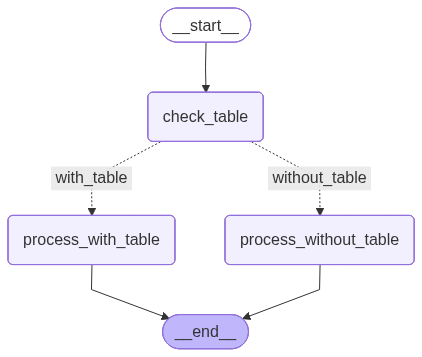

In [82]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from unstructured.partition.pdf import partition_pdf
from unstructured.documents.elements import Table

# 상태 정의
class State(TypedDict):
    file_path: str  # 입력 PDF 파일 경로
    elements: list  # PDF 문서 요소들
    has_table: bool  # 테이블 존재 여부
    table_data: list  # 테이블 데이터 (있는 경우)
    content: str  # 일반 텍스트 내용

def check_table(state: State):
    """PDF 문서를 파싱하고 테이블 존재 여부 확인"""
    elements = partition_pdf(
        filename=state["file_path"],
        strategy="hi_res", # 고해상도 파티셔닝 전략 사용
        infer_table_structure=True, # 표 구조를 자동으로 추론하여 HTML 형식으로 변환
        languages=["eng", "kor"], # 영어와 한국어 문서 처리 지원
        extract_images_in_pdf=False, # PDF 내 이미지 추출 활성화
        )


    has_table = any(isinstance(element, Table) for element in elements)
    
    return {
        "elements": elements,
        "has_table": has_table
    }

def process_with_table(state: State):
    """테이블이 있는 경우 처리"""
    tables = []
    text_content = []
    
    for element in state["elements"]:
        if isinstance(element, Table):
            tables.append({
                "html": element.metadata.text_as_html,
                "text": str(element)
            })
        else:
            text_content.append(str(element))
    
    return {
        "table_data": tables,
        "content": "\n".join(text_content)
    }

def process_without_table(state: State):
    """테이블이 없는 경우 처리"""
    text_content = [str(element) for element in state["elements"]]
    
    return {
        "content": "\n".join(text_content)
    }

def router(state: State) -> Literal["with_table", "without_table"]:
    """테이블 유무에 따른 라우팅"""
    return "with_table" if state["has_table"] else "without_table"

# 그래프 구성
workflow = StateGraph(State)

# 노드 추가
workflow.add_node("check_table", check_table)
workflow.add_node("process_with_table", process_with_table)
workflow.add_node("process_without_table", process_without_table)

# 엣지 추가
workflow.add_edge(START, "check_table")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "check_table",
    router,
    {
        "with_table": "process_with_table",
        "without_table": "process_without_table"
    }
)

workflow.add_edge("process_with_table", END)
workflow.add_edge("process_without_table", END)

# 그래프 컴파일
graph = workflow.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))  

In [83]:

import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('unstructured').setLevel(logging.ERROR)


In [84]:
# 테이블이 있는 PDF 파일 경로
file_path_with_table = "data/리비안_KR_with_table.pdf"

# 그래프 실행
result_with_table = graph.invoke({"file_path": file_path_with_table})

# 결과 확인
if result_with_table["has_table"]:
    print("Tables found:", len(result_with_table["table_data"]))
    print("\nTable HTML examples:")
    for table in result_with_table["table_data"][:2]:  # 처음 2개 테이블만 출력
        print(table["html"][:200] + "...")  # HTML의 처음 200자만 출력
        
print("\nExtracted content length:", len(result_with_table["content"]))

Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBB

Tables found: 1

Table HTML examples:
<table><thead><tr><th>2020</th><th>0</th><th>-1,018</th><th>4,602</th></tr></thead><tbody><tr><td>2021</td><td>55</td><td>-4,688</td><td>22,294</td></tr><tr><td>2022</td><td>1,658</td><td>-6,752</td><...

Extracted content length: 3196


In [85]:
# 테이블이 없는 PDF 파일 경로
file_path_without_table = "data/리비안_KR_without_table.pdf"

# 그래프 실행
result_without_table = graph.invoke({"file_path": file_path_without_table})

# 결과 확인
if result_without_table["has_table"]:
    print("Tables found:", len(result_without_table["table_data"]))
    print("\nTable HTML examples:")
    for table in result_without_table["table_data"][:2]:  # 처음 2개 테이블만 출력
        print(table["html"][:200] + "...")  # HTML의 처음 200자만 출력

print("\nExtracted content length:", len(result_without_table["content"]))

Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBB


Extracted content length: 3130
